# Computing second-order shear statistics on a shape catalog

In this notebooks we compute the second-order shear correlation functions on a realistic shape catalog and transform them to related statistics, such as Map2, COSEBI and pure-mode correlation functions.

In [1]:
from astropy.table import Table
from itertools import combinations_with_replacement
import numpy as np
from matplotlib import pyplot as plt

import orpheus

## Obtaining a realistic mock shape catalog

We will run this notebook using a mocks shape catalog from the [SLICS](https://slics.roe.ac.uk/) ensemble. First, let us download this catalog and read in its contents.

**Note:** If you want to run the notebook yourself, you need to update the `savepath_SLICS` variable.

In [2]:
catname = "GalCatalog_LOS1.fits"
path_to_SLICS = "http://cuillin.roe.ac.uk/~jharno/SLICS/MockProducts/KiDS450/" + catname
savepath_SLICS = "/vol/euclidraid4/data/lporth/HigherOrderLensing/Mocks/SLICS_KiDS450/"

In [3]:
#!wget {path_to_SLICS} -P {savepath_SLICS}

In [4]:
slicscat = Table.read(savepath_SLICS + catname)
print(slicscat.keys())

['x_arcmin', 'y_arcmin', 'z_spectroscopic', 'z_photometric', 'shear1', 'shear2', 'eps_obs1', 'eps_obs2']


## Initialize the catalog instance

As we are dealing with an ellipticity catalog, we need to use the `SpinTracerCatalog` class and set the value of `spin` to two.

In [5]:
shapecat = orpheus.SpinTracerCatalog(spin=2,
                                     pos1=slicscat["x_arcmin"],
                                     pos2=slicscat["y_arcmin"],
                                     tracer_1=slicscat["shear1"],
                                     tracer_2=slicscat["shear2"])

In [6]:
print("Number of galaxies:%i --> effective nbar: %.3f/arcmin^2 on %.2f deg^2"%(
    shapecat.ngal, shapecat.ngal/(shapecat.len1*shapecat.len2), shapecat.len1*shapecat.len2/3600.))

Number of galaxies:3070801 --> effective nbar: 8.530/arcmin^2 on 100.00 deg^2


## Computation of the shear 2pcf

For computing the second-order shear correlation functions we need to invoke the `GGCorrelation` class. In principle, it is only required to define a binning for the 2pcf (given my the range of the bins and the number of bins).

**Notes**

* Instead of the number of bins you can also specify the logarithmic bin-width `binsize`. However, the final value of `binsize` might differ slightly from the provided one as we fix the values for the binning range and then choose the largest possible value of `binsize` that is smaller or equal to the input value for `binsize`.

* If no further parameters are passed, the default setup chooses the some accelerations of the discrete multipole estimator renders fairly accurate results for the 2pcf itself and percent-level accuracy for the second-order aperture statistics. In case you want a different setup than the default results you can change the parameters of the parent `BinnedNPCF` class.

* Per default, `orpheus` does not double count the different tracer pairs. The only effect of this is that the imaginary part of $\xi_+$ does not vanish. In case you want to include double-counting you can do this by setting `do_dc=True` in the `process` method.

In [7]:
orpheus.GGCorrelation.__init__

<function orpheus.npcf_second.GGCorrelation.__init__(self, min_sep, max_sep, process_spherical=False, **kwargs)>

In [8]:
orpheus.BinnedNPCF.__init__

<function orpheus.npcf_base.BinnedNPCF.__init__(self, order, spins, n_cfs, min_sep, max_sep, nbinsr=None, binsize=None, nbinsphi=100, nmaxs=30, method='DoubleTree', multicountcorr=True, shuffle_pix=0, tree_alpha=None, tree_mincellsize=0.1, tree_maxcellsize=4.0, tree_resos=[0, 0.25, 0.5, 1.0, 2.0], tree_redges=None, rmin_pixsize=20, resoshift_leafs=0, minresoind_leaf=None, maxresoind_leaf=None, methods_avail=['Discrete', 'Tree', 'BaseTree', 'DoubleTree'], verbosity=0, nthreads=16, sep_units='arcmin')>

In [9]:
min_sep = 0.5
max_sep = 150.
binsize = 0.15
nthreads=48

In [10]:
twopcf = orpheus.GGCorrelation(min_sep=min_sep, max_sep=max_sep, binsize=binsize, nthreads=nthreads, verbosity=2)

In [11]:
%%time
twopcf.process(shapecat, do_dc=False)

....................................................................................................CPU times: user 2min 46s, sys: 4.59 s, total: 2min 50s

Wall time: 4.63 s


## Computation of the aperture mass

The integral transormation between the shear 2PCF and the second-order aperture statistics can be done by calling the `GGCorrelation.computeMap2` method.

**Notes**

* One should only trust the second-order aperture statistics for radii $R\in[\alpha\,\theta_{\rm min}, \beta\,\theta_{\rm max}]$, where $\alpha\approx 15$  and $\beta \approx 0.1$. In the plot below this range is indicated by the dashed vertical lines.

* Furthermore, the binning should be sufficiently fine, i.e. the value of the `GGCorrelation.binsize` attribute should be less than `0.1` for an accuracy of about one per cent.

In [12]:
apradii = np.geomspace(1,32,17)
map2 = twopcf.computeMap2(apradii)

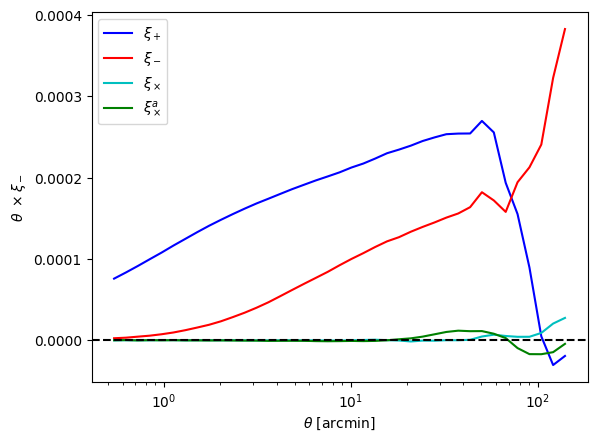

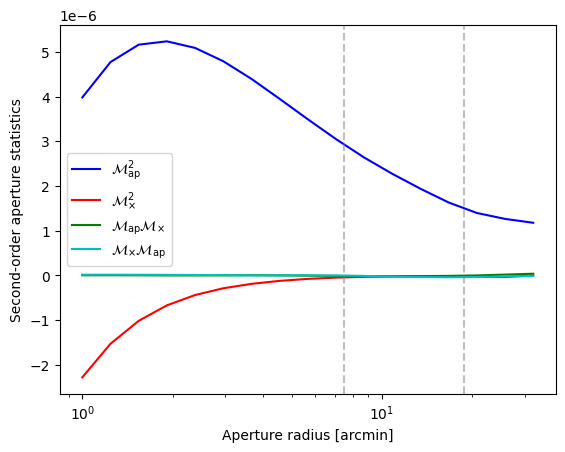

In [13]:
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*twopcf.xip[0].real, 'b-', label=r'$\xi_+$')
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*twopcf.xim[0].real, 'r-', label=r'$\xi_-$')
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*twopcf.xim[0].imag, 'c-', label=r'$\xi_\times$')
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*twopcf.xip[0].imag, 'g-', label=r'$\xi_\times^a$')

plt.axhline(0, color='k', ls='--')
plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r"$\theta \ \times \xi_-$") 
plt.legend()
plt.show()

plt.semilogx(apradii, map2[0,0], 'b-', label=r'$\mathcal{M}_{\mathrm{ap}}^2$')
plt.semilogx(apradii, map2[2,0], 'r-', label=r'$\mathcal{M}_{\times}^2$')
plt.semilogx(apradii, map2[1,0], 'g-', label=r'$\mathcal{M}_{\mathrm{ap}}\mathcal{M}_{\times}$')
plt.semilogx(apradii, map2[3,0], 'c-', label=r'$\mathcal{M}_{\times}\mathcal{M}_{\mathrm{ap}}$')
plt.axvline(15*twopcf.bin_edges[0],color='grey', ls='--', alpha=0.5)
plt.axvline(0.125*twopcf.bin_edges[-1],color='grey', ls='--', alpha=0.5)
plt.xlabel('Aperture radius [arcmin]')
plt.ylabel("Second-order aperture statistics") 
plt.legend()
plt.show()

## Computation of the COSEBI and pure-mode correlation functions

A more suitable set of statistics to quantify the information content and/or investigate B-mode leakage are the COSEBI and the pure-mode correlation functions. Those can be computed by using the `computepuremode` and `computecosebi` methods. 

Notes:
* The COSEBI implemantation closely follows the implementation of cosmopipe, but it uses an accelerated method to compute the $T_{-,n}$ filters. For an accurate computation of the roots of the filter functions we make use of the `mpmath` module (as does cosmopipe)
* For an accurate computation of those two statistics the 2PCFs also have to be evaluated at a fairly high radial resolution, i.e. a binsize of about 1e-2.

In [14]:
xip_pure, xim_pure = twopcf.computepuremode()
coarse_cosebi = twopcf.computecosebi(Nmax=20)

Let us now compute the pure-mode correlation functions and the COSEBI using a finely binned 2PCF. 

Notes
* As compared to other treecodes we note that the runtime of this computation does not increase as compared to the coarser resolution from before. This is because the runtime complexity is fully determined by the allowed resolutions of the tree and the value of `rmin_pixsize`
* For the chosen binning the pixel sizes may become larger than the actual bins which might lead to an uneven sampling if the galaxies are placed at the pixel center-of-mass. We can circumvent this by setting the `shuffle_pix` parameter to one, which leads to a random shuffling of the tracer position within the pixel. This inevitably leads to multiple wrong bin assignments and a moderate loss in angular resolution, but at least the former inaccuracy will cancel out on average.

In [15]:
%%time
twopcf_fine = orpheus.GGCorrelation(min_sep=min_sep, max_sep=max_sep, binsize=1e-3, nthreads=nthreads, verbosity=2, 
                                    shuffle_pix=1, rmin_pixsize=twopcf.rmin_pixsize, tree_resos=twopcf.tree_resos)
twopcf_fine.process(shapecat)

....................................................................................................
CPU times: user 3min 8s, sys: 3.85 s, total: 3min 12s
Wall time: 5.04 s


In [16]:
fine_cosebi = twopcf_fine.computecosebi(Nmax=20)
fxip_pure, fxim_pure = twopcf_fine.computepuremode()

Now let us plot the statistics the fine binning choice. We note
* For the cosebis the fine binning to accurately resolve the higher modes
* For the pure-mode correlation functions we see that for progressively larger scales there seems to be some visible increase in scatter. This is due to the fact that we redistributed the galaxies while constructing the multihash. You can verify by yourself that the range and scale of the scatter varies with different choices for `rmin_pixsize` and `tree_resos`. Also note that there is no bias but merely noise added.

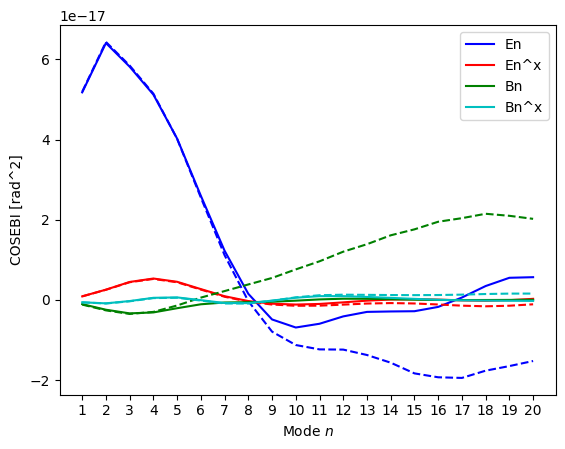

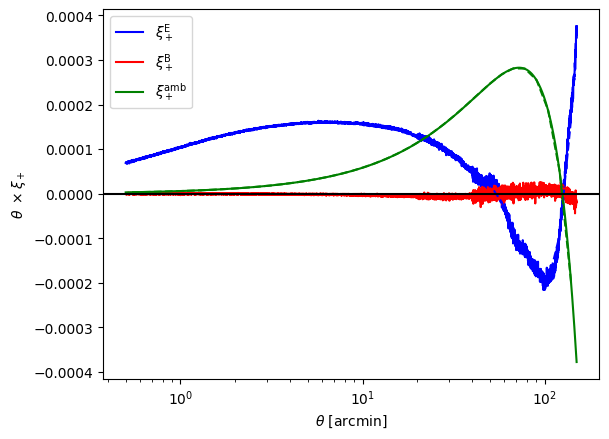

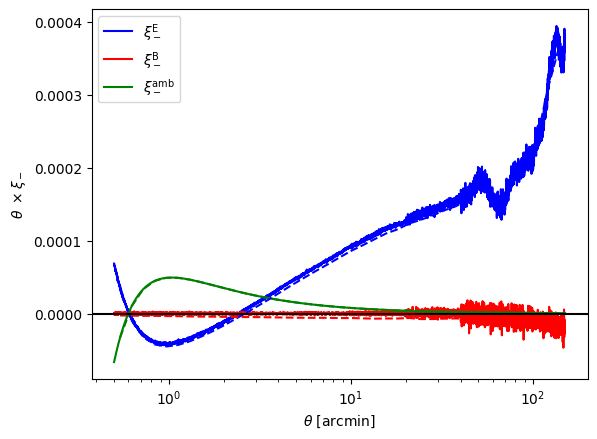

In [17]:
rad2arcminsq = (2*np.pi/360/60)**2
plt.plot(np.arange(1,21),fine_cosebi[0,0]*rad2arcminsq, 'b-', label="En")
plt.plot(np.arange(1,21),coarse_cosebi[0,0]*rad2arcminsq,'b--')
plt.plot(np.arange(1,21),fine_cosebi[1,0]*rad2arcminsq, 'r-', label="En^x")
plt.plot(np.arange(1,21),coarse_cosebi[1,0]*rad2arcminsq,'r--')
plt.plot(np.arange(1,21),fine_cosebi[2,0]*rad2arcminsq, 'g-', label="Bn")
plt.plot(np.arange(1,21),coarse_cosebi[2,0]*rad2arcminsq, 'g--')
plt.plot(np.arange(1,21),fine_cosebi[3,0]*rad2arcminsq, 'c-', label="Bn^x")
plt.plot(np.arange(1,21),coarse_cosebi[3,0]*rad2arcminsq, 'c--')
plt.legend()
_=plt.xticks(np.arange(1,21))
plt.xlabel("Mode $n$")
plt.ylabel("COSEBI [rad^2]")
plt.show()

fxip_pure, fxim_pure = twopcf_fine.computepuremode()
plt.semilogx(twopcf_fine.bin_centers_mean,twopcf_fine.bin_centers_mean*fxip_pure[0,0],'b-',label=r"$\xi_+^\mathrm{E}$")
plt.semilogx(twopcf_fine.bin_centers_mean,twopcf_fine.bin_centers_mean*fxip_pure[1,0],'r-',label=r"$\xi_+^\mathrm{B}$")
plt.semilogx(twopcf_fine.bin_centers_mean,twopcf_fine.bin_centers_mean*fxip_pure[2,0],'g-',label=r"$\xi_+^\mathrm{amb}$")
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*xip_pure[0,0],'b--')
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*xip_pure[1,0],'r--')
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*xip_pure[2,0],'g--')
plt.axhline(0,color='k',ls='-')
plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r"$\theta \ \times \xi_+$") 
plt.legend()
plt.show()
plt.semilogx(twopcf_fine.bin_centers_mean,twopcf_fine.bin_centers_mean*fxim_pure[0,0],'b-',label=r"$\xi_-^\mathrm{E}$")
plt.semilogx(twopcf_fine.bin_centers_mean,twopcf_fine.bin_centers_mean*fxim_pure[1,0],'r-',label=r"$\xi_-^\mathrm{B}$")
plt.semilogx(twopcf_fine.bin_centers_mean,twopcf_fine.bin_centers_mean*fxim_pure[2,0],'g-',label=r"$\xi_-^\mathrm{amb}$")
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*xim_pure[0,0],'b--')
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*xim_pure[1,0],'r--')
plt.semilogx(twopcf.bin_centers_mean,twopcf.bin_centers_mean*xim_pure[2,0],'g--')
plt.axhline(0,color='k',ls='-')
plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r"$\theta \ \times \xi_-$") 
plt.legend()
plt.show()

Finally, let us make sure that the expressions have converged for a binsize of 0.01 by comparing against a computation using ten times finer bins.

In [18]:
%%time
twopcf_vfine = orpheus.GGCorrelation(min_sep=min_sep, max_sep=max_sep, binsize=1e-3, nthreads=nthreads, verbosity=2, shuffle_pix=1)
twopcf_vfine.process(shapecat)
vfine_cosebi = twopcf_vfine.computecosebi(Nmax=20)
vfxip_pure, vfxim_pure = twopcf_vfine.computepuremode()

....................................................................................................
CPU times: user 3min 28s, sys: 21.7 s, total: 3min 49s
Wall time: 10.2 s


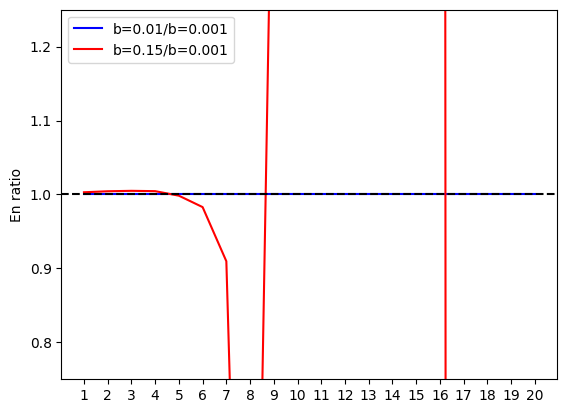

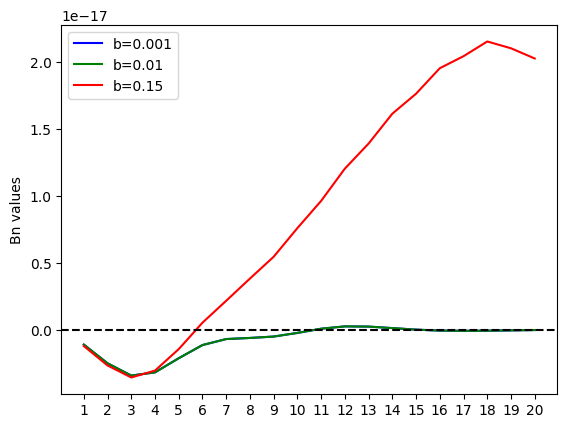

In [19]:
plt.plot(np.arange(1,21),fine_cosebi[0,0]/vfine_cosebi[0,0], 'b-', label="b=0.01/b=0.001")
plt.plot(np.arange(1,21),coarse_cosebi[0,0]/vfine_cosebi[0,0], 'r-', label="b=0.15/b=0.001")
plt.axhline(1,color='k',ls='--')
plt.ylim(0.75,1.25)
_=plt.xticks(np.arange(1,21))
plt.legend()
plt.ylabel("En ratio")
plt.show()

plt.plot(np.arange(1,21), vfine_cosebi[2,0]*rad2arcminsq, 'b-', label="b=0.001")
plt.plot(np.arange(1,21), fine_cosebi[2,0]*rad2arcminsq, 'g-',  label="b=0.01")
plt.plot(np.arange(1,21), coarse_cosebi[2,0]*rad2arcminsq, 'r-',label="b=0.15")
plt.axhline(0,color='k',ls='--')
_=plt.xticks(np.arange(1,21))
plt.legend()
plt.ylabel("Bn values")
plt.show()
